In [1]:
import Pkg;
Pkg.activate(@__DIR__);
Pkg.instantiate();

  Activating project at `~/OneDrive_xwc@zju.edu.cn/optimal-control/my-notes/code/with-notes/lec5`


In [2]:
using LinearAlgebra
using ForwardDiff
using PyPlot
using LaTeXStrings
using JupyterFormatter
enable_autoformat()
PyPlot.rc("text", usetex = true)
PyPlot.rc("font", family = "Times New Roman")
PyPlot.rc("text.latex", preamble = "\\usepackage{{amsmath}}")

In [3]:
Q = Diagonal([0.5; 1])
function f(x)
    return 0.5 * (x - [1; 0])' * Q * (x - [1; 0])
end
gradient_f = x -> ForwardDiff.gradient(x -> f(x), x);
hessian_f = x -> ForwardDiff.hessian(x -> f(x), x);

In [7]:
function c(x)
    return x[1]^2 + 2 * x[1] - x[2]
end
gradient_c = x -> ForwardDiff.gradient(x -> c(x), x);  # [2*x[1]+2 -1]

In [8]:
let
    x0 = [0, 0]
    @show f(x0)
    @show gradient_f(x0)
    @show hessian_f(x0)
    @show c(x0)
    @show gradient_c(x0)
end;

f(x0) = 0.25
gradient_f(x0) = [-0.5, 0.0]
hessian_f(x0) = [0.5 0.0; 0.0 1.0]
c(x0) = 0
gradient_c(x0) = [2, -1]


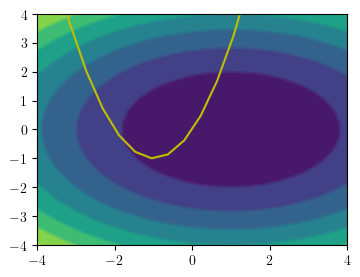

In [9]:
function plot_landscape()
    n_sample = 20
    x_sample = kron(ones(n_sample), LinRange(-4, 4, n_sample)')
    y_sample = kron(ones(n_sample)', LinRange(-4, 4, n_sample))
    z = [f([x, y]) for (x, y) in zip(x_sample, y_sample)]
    figure(figsize = (4, 3))
    contourf(x_sample, y_sample, z)
    contour(x_sample, y_sample, z)
    xc = LinRange(-4, 4, n_sample)
    plot(xc, [c([x 0]) for x in xc], "y")
    xlim([-4, 4])
    ylim([-4, 4])
end
plot_landscape();

### Gauss-Newton

In [35]:
function gauss_newton_step(x, lambda)
    H = hessian_f(x)
    C = gradient_c(x)
    delta_z = [H C; C' 0] \ [-gradient_f(x) - C * lambda; -c(x)]
    delta_x = delta_z[1:2]
    delta_lambda = delta_z[3]
    return delta_x, delta_lambda
end

gauss_newton_step (generic function with 1 method)

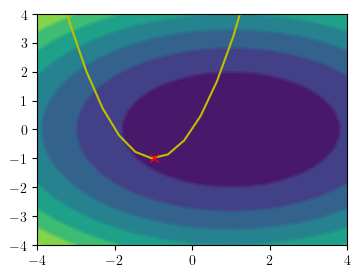

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7ff2f0067550>

In [51]:
x_guess = [-1; -1]
lambda_guess = [0.0]
plot_landscape()
plot(x_guess[1], x_guess[2], "rx")

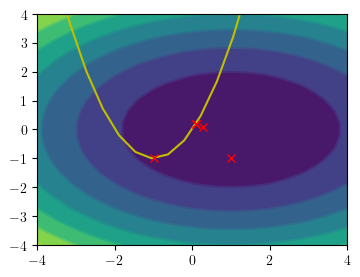

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7ff3208e4610>

In [40]:
delta_x, delta_lambda = gauss_newton_step(x_guess[:, end], lambda_guess[end])
x_guess = [x_guess x_guess[:, end] + delta_x]
lambda_guess = [lambda_guess lambda_guess[end] + delta_lambda]
plot_landscape()
plot(x_guess[1, :], x_guess[2, :], "rx")

### Merit Function

#### KKT Residual

In [42]:
function P(x_)  # KKT residual
    x = x_[1:2]
    lambda = x_[3]
    gradient_L = [-gradient_f(x) - gradient_c(x) * lambda; -c(x)]
    return 0.5 * dot(gradient_L, gradient_L)
end
gradient_P = x_ -> ForwardDiff.gradient(x -> P(x), x_)

#51 (generic function with 1 method)

#### Weighted Sum

In [56]:
rho = 1.0
function P(x_)
    x = x_[1:2]
    lambda = x_[3]
    f(x) + rho * norm(c(x), 1)
end
gradient_P = x_ -> ForwardDiff.gradient(x -> P(x), x_)

#55 (generic function with 1 method)

#### Augmented Lagrangian

In [62]:
rho = 1.0
function P(x_)
    x = x_[1:2]
    lambda = x_[3]
    f(x) + lambda' * c(x) + 0.5 * rho * dot(c(x), c(x))
end
gradient_P = x_ -> ForwardDiff.gradient(x -> P(x), x_)

#59 (generic function with 1 method)

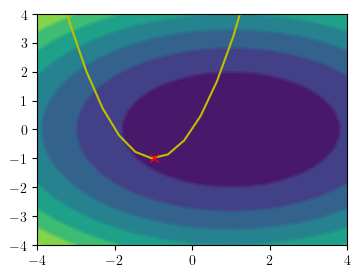

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7ff2f0021cd0>

In [63]:
x_guess = [-1; -1]
lambda_guess = [0.0]
plot_landscape()
plot(x_guess[1], x_guess[2], "rx")

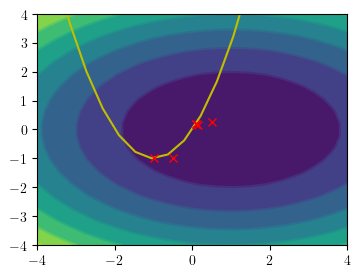

1

In [68]:
delta_x, delta_lambda = gauss_newton_step(x_guess[:, end], lambda_guess[end])
alpha = 1
while P(x_guess[:, end] + alpha * delta_x, lambda_guess[end] + alpha * delta_lambda) >
      P(x_guess[:, end], lambda_guess[end]) +
      0.01 *
      alpha *
      dot(gradient_P([x_guess[:, end]; lambda_guess[end]]), [delta_x; delta_lambda])
    alpha = 0.5 * alpha
end
x_guess = [x_guess x_guess[:, end] + alpha * delta_x]
lambda_guess = [lambda_guess lambda_guess[end] + alpha * delta_lambda]
plot_landscape()
plot(x_guess[1, :], x_guess[2, :], "rx")
alpha